# Customer Analytics: Churn Risk, K-Means Segmentation, CLTV & Model Evaluation

Notebook ini melanjutkan pipeline dari tahap sebelumnya (RFM + Cohort) ke pemodelan yang lebih dalam:

1. **Churn Risk Scoring** — Isolation Forest untuk deteksi anomali perilaku
2. **Segmentasi ML** — K-Means berbasis fitur RFM
3. **Customer Lifetime Value (CLTV)** — Model probabilistik BG/NBD + Gamma-Gamma
4. **Integrasi & Prioritas Aksi Marketing**
5. **Evaluasi Model** — Silhouette, Davies-Bouldin, MAE, stabilitas bootstrapping
6. **Export Aset Model**

**Input yang dibutuhkan:** `rfm_customer_table.csv` dan `clean_transactions.csv` (output dari notebook sebelumnya).

---
## 1. Setup

In [1]:
# Install lifetimes jika belum tersedia
# !pip install lifetimes -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    calinski_harabasz_score, classification_report,
    mean_absolute_error
)
from scipy import stats
from scipy.stats import spearmanr

sns.set_theme(style="whitegrid")

In [3]:
# Sesuaikan path dengan lokasi file di mesin kamu
RFM_PATH          = 'rfm_customer_table.csv'
TRANSACTIONS_PATH = 'clean_transactions.csv'

rfm      = pd.read_csv(RFM_PATH, index_col='Customer ID')
df_clean = pd.read_csv(TRANSACTIONS_PATH, parse_dates=['InvoiceDate'])

print(f"RFM table        : {rfm.shape[0]:,} customers, {rfm.shape[1]} kolom")
print(f"Transactions     : {df_clean.shape[0]:,} baris")

RFM table        : 5,878 customers, 9 kolom
Transactions     : 805,549 baris


---
## 2. Churn Risk Scoring — Isolation Forest

Isolation Forest mendeteksi anomali perilaku pada ruang RFM. Customer yang terisolasi dari populasi normal mendapat **churn risk score** tinggi (0–100).

Parameter `contamination=0.05` berarti sekitar 5% customer dianggap anomali.

In [4]:
FEATURES = ['Recency', 'Frequency', 'Monetary']
X = rfm[FEATURES]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(X_scaled)

rfm['anomaly_label'] = iso_forest.predict(X_scaled)
rfm['anomaly_score'] = iso_forest.decision_function(X_scaled)

print(f"Customer terdeteksi anomali (label -1): {(rfm['anomaly_label'] == -1).sum():,}")

Customer terdeteksi anomali (label -1): 294


In [5]:
# Normalisasi anomaly_score ke skala 0–100
# Skor anomali rendah = lebih berisiko → diinvert agar skor tinggi = risiko tinggi
min_score = rfm['anomaly_score'].min()
max_score = rfm['anomaly_score'].max()

rfm['churn_risk_score'] = 100 * (1 - (rfm['anomaly_score'] - min_score) / (max_score - min_score))

top_risk = rfm.sort_values('churn_risk_score', ascending=False).head(20)
print("Top 20 Customer Berisiko Tinggi:")
top_risk[['Recency', 'Frequency', 'Monetary', 'Segment', 'churn_risk_score']]

Top 20 Customer Berisiko Tinggi:


,Recency,Frequency,Monetary,Segment,churn_risk_score
Customer ID,,,,,
14911.0,1,398,295972.630,Champions,100.000000
14646.0,2,151,528602.520,Champions,98.656775
18102.0,1,145,608821.650,Champions,98.656775
14156.0,10,156,313946.370,Champions,98.535159
13694.0,4,143,196482.810,Champions,98.170803
13089.0,3,203,116737.860,Champions,96.816167
15311.0,1,208,116771.160,Champions,96.455297
15061.0,4,127,137818.520,Champions,95.855472
17850.0,372,155,56600.080,Can't Lose,95.401844


---
## 3. Segmentasi K-Means

K-Means dijalankan pada fitur RFM yang sudah ditransformasi log (untuk menangani distribusi skewed) dan di-scale. Jumlah cluster optimal ditentukan via **Elbow Method**.

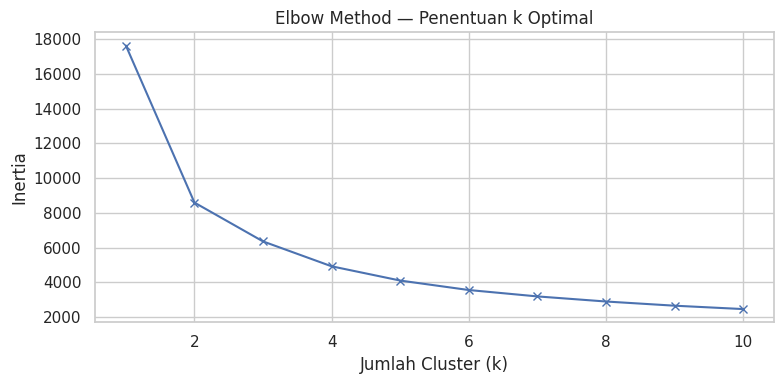

In [6]:
X_log        = X.apply(lambda col: np.log(col + 1))
X_log_scaled = scaler.fit_transform(X_log)

inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_log_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Penentuan k Optimal')
plt.tight_layout()
plt.show()

In [7]:
# Ganti nilai K_OPTIMAL sesuai hasil elbow di atas
K_OPTIMAL = 4

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
rfm['KMeansCluster'] = kmeans.fit_predict(X_log_scaled)

cluster_profile = rfm.groupby('KMeansCluster').agg(
    Jumlah_Customer = ('Recency',   'count'),
    Recency_Rata2   = ('Recency',   'mean'),
    Frequency_Rata2 = ('Frequency', 'mean'),
    Monetary_Rata2  = ('Monetary',  'mean')
).round(2)

print("Profil per Cluster K-Means:")
cluster_profile

Profil per Cluster K-Means:


,Jumlah_Customer,Recency_Rata2,Frequency_Rata2,Monetary_Rata2
KMeansCluster,,,,
0,1188,27.43,19.34,11014.37
1,1974,395.86,1.38,325.75
2,1465,227.87,5.10,2002.10
3,1251,28.44,3.04,865.11


In [8]:
# Label bisnis cluster — sesuaikan berdasarkan profil di atas
cluster_map = {
    0: 'High Value',
    1: 'Hibernating',
    2: 'At Risk',
    3: 'New / Occasional'
}
rfm['KMeansSegment'] = rfm['KMeansCluster'].map(cluster_map)

---
## 4. Customer Lifetime Value (CLTV)

CLTV diprediksi menggunakan dua model probabilistik:
- **BG/NBD (BetaGeoFitter)** — memprediksi jumlah transaksi di masa depan
- **Gamma-Gamma** — memprediksi nilai rata-rata per transaksi

Keduanya dikombinasikan untuk menghasilkan estimasi CLTV 6 bulan ke depan.

In [9]:
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

observation_end = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

cltv_df = summary_data_from_transaction_data(
    df_clean,
    customer_id_col='Customer ID',
    datetime_col='InvoiceDate',
    monetary_value_col='TotalPrice',
    observation_period_end=observation_end
)

# BG/NBD hanya valid untuk repeat customers (frequency > 0)
# Gamma-Gamma hanya valid untuk monetary_value > 0
cltv_df = cltv_df[(cltv_df['frequency'] > 0) & (cltv_df['monetary_value'] > 0)]

print(f"Customer untuk pemodelan CLTV: {len(cltv_df):,}")

Customer untuk pemodelan CLTV: 4,189


In [10]:
# Train BG/NBD
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(cltv_df['frequency'], cltv_df['recency'], cltv_df['T'])

cltv_df['expected_purchases_90d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    90, cltv_df['frequency'], cltv_df['recency'], cltv_df['T']
)

# Train Gamma-Gamma
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(cltv_df['frequency'], cltv_df['monetary_value'])

# Prediksi CLTV 6 bulan
cltv_df['cltv_6_months'] = ggf.customer_lifetime_value(
    bgf,
    cltv_df['frequency'],
    cltv_df['recency'],
    cltv_df['T'],
    cltv_df['monetary_value'],
    time=6,
    discount_rate=0.01
)

cltv_df['CLTVSegment'] = pd.qcut(cltv_df['cltv_6_months'], 4, labels=['D', 'C', 'B', 'A'])

print("Distribusi CLTV Segment:")
print(cltv_df['CLTVSegment'].value_counts().sort_index())
cltv_df.head()

Distribusi CLTV Segment:
CLTVSegment
D    1048
C    1047
B    1047
A    1047
Name: count, dtype: int64


,frequency,recency,T,monetary_value,expected_purchases_90d,cltv_6_months,CLTVSegment
Customer ID,,,,,,,
12346.0,7.0,400.0,726.0,11066.637143,0.465366,10150.624586,A
12347.0,7.0,402.0,405.0,717.398571,1.471954,2076.853984,A
12348.0,4.0,363.0,439.0,449.310000,0.858751,774.677317,B
12349.0,3.0,571.0,590.0,1120.056667,0.561154,1281.899088,A
12352.0,8.0,356.0,393.0,338.261250,1.666669,1105.889693,A


---
## 5. Integrasi & Prioritas Aksi Marketing

Semua output digabung menjadi satu dataframe. Kolom `RecommendedAction` dibuat berdasarkan kombinasi CLTV segment dan churn risk score.

In [11]:
final_df = rfm.join(cltv_df[['cltv_6_months', 'CLTVSegment']], how='left')
final_df['cltv_6_months'] = final_df['cltv_6_months'].fillna(0)
final_df['CLTVSegment']   = final_df['CLTVSegment'].cat.add_categories('Unknown').fillna('Unknown')

def recommend_action(row):
    if row['CLTVSegment'] in ['A', 'B'] and row['churn_risk_score'] > 75:
        return 'Win-back Priority'
    elif row['CLTVSegment'] in ['A', 'B'] and row['churn_risk_score'] <= 50:
        return 'Loyalty Maintenance'
    elif row['CLTVSegment'] in ['C', 'D'] and row['churn_risk_score'] > 75:
        return 'Low-cost Automation'
    elif row['Segment'] == 'New Customers':
        return 'Onboarding Campaign'
    else:
        return 'Standard Nurture'

final_df['RecommendedAction'] = final_df.apply(recommend_action, axis=1)

print("Distribusi Recommended Action:")
print(final_df['RecommendedAction'].value_counts())
final_df.head()

Distribusi Recommended Action:
RecommendedAction
Standard Nurture       3830
Loyalty Maintenance    1945
Onboarding Campaign      54
Win-back Priority        43
Low-cost Automation       6
Name: count, dtype: int64


,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RF_Score,Segment,Country,anomaly_label,anomaly_score,churn_risk_score,KMeansCluster,KMeansSegment,cltv_6_months,CLTVSegment,RecommendedAction
Customer ID,,,,,,,,,,,,,,,,,
12346.0,326,12,77556.46,2,5,5,25,Can't Lose,United Kingdom,-1,-0.178270,80.472233,0,High Value,10150.624586,A,Win-back Priority
12347.0,2,8,5633.32,5,4,5,54,Champions,Iceland,1,0.113500,16.851317,0,High Value,2076.853984,A,Loyalty Maintenance
12348.0,75,5,2019.40,3,4,4,34,Loyal Customers,Finland,1,0.170157,4.497094,2,At Risk,774.677317,B,Loyalty Maintenance
12349.0,19,4,4428.69,5,3,5,53,Potential Loyalists,Italy,1,0.121584,15.088455,3,New / Occasional,1281.899088,A,Loyalty Maintenance
12350.0,310,1,334.40,2,1,2,21,Hibernating,Norway,1,0.155442,7.705682,1,Hibernating,0.000000,Unknown,Standard Nurture


---
## 6. Evaluasi Model

### 6.1 Evaluasi K-Means Segmentation

In [12]:
sil = silhouette_score(X_log_scaled, rfm['KMeansCluster'])
db  = davies_bouldin_score(X_log_scaled, rfm['KMeansCluster'])
ch  = calinski_harabasz_score(X_log_scaled, rfm['KMeansCluster'])

print(f"Silhouette Score     : {sil:.3f}  → mendekati 1 = baik (>0.25 cukup untuk data retail)")
print(f"Davies-Bouldin Index : {db:.3f}   → lebih kecil = lebih baik")
print(f"Calinski-Harabasz    : {ch:.1f}  → lebih besar = lebih baik")

Silhouette Score     : 0.365  → mendekati 1 = baik (>0.25 cukup untuk data retail)
Davies-Bouldin Index : 0.930   → lebih kecil = lebih baik
Calinski-Harabasz    : 5061.7  → lebih besar = lebih baik


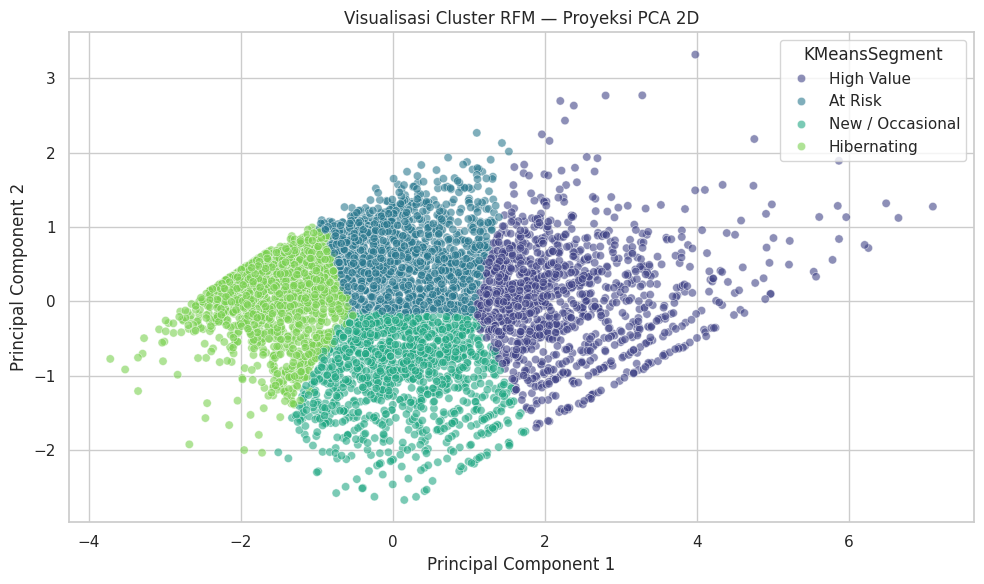

In [13]:
# Visualisasi cluster dengan PCA 2D
pca      = PCA(n_components=2)
pca_data = pca.fit_transform(X_log_scaled)

rfm['pca1'] = pca_data[:, 0]
rfm['pca2'] = pca_data[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='pca1', y='pca2', hue='KMeansSegment', data=rfm, palette='viridis', alpha=0.6)
plt.title('Visualisasi Cluster RFM — Proyeksi PCA 2D')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

### 6.2 Evaluasi Churn Risk Score — Isolation Forest vs LOF

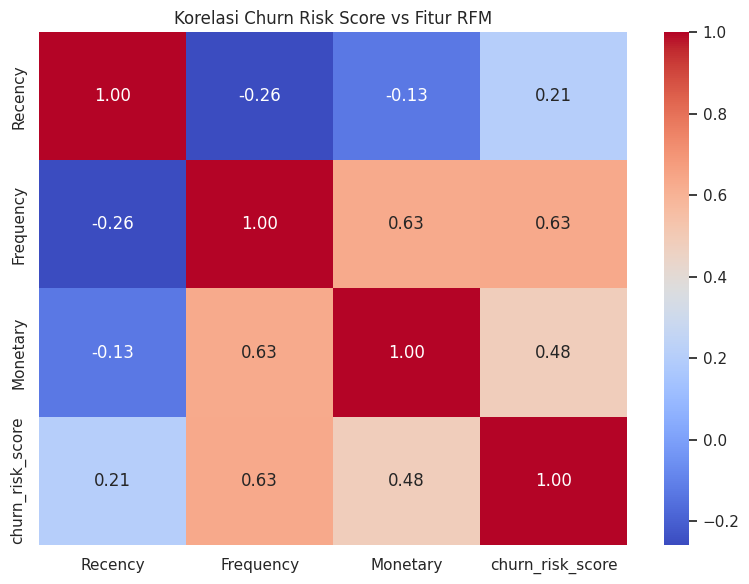

Catatan: Korelasi risk score dengan Recency yang tinggi mengonfirmasi logika bisnis model.


In [14]:
# Heatmap korelasi risk score dengan fitur RFM
correlation = rfm[['Recency', 'Frequency', 'Monetary', 'churn_risk_score']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Churn Risk Score vs Fitur RFM')
plt.tight_layout()
plt.show()

print("Catatan: Korelasi risk score dengan Recency yang tinggi mengonfirmasi logika bisnis model.")

In [15]:
# Challenger model: Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, novelty=True)
lof.fit(X_scaled)

lof_raw  = lof.negative_outlier_factor_
min_lof  = lof_raw.min()
max_lof  = lof_raw.max()

rfm['lof_score_raw']  = lof_raw
rfm['churn_risk_lof'] = 100 * (1 - (lof_raw - min_lof) / (max_lof - min_lof))

corr_if  = rfm['churn_risk_score'].corr(rfm['Recency'])
corr_lof = rfm['churn_risk_lof'].corr(rfm['Recency'])

top_if  = set(rfm.sort_values('churn_risk_score', ascending=False).head(100).index)
top_lof = set(rfm.sort_values('churn_risk_lof',   ascending=False).head(100).index)
overlap = len(top_if & top_lof)

print("=== Perbandingan Isolation Forest vs LOF ===")
print(f"Korelasi IF  vs Recency : {corr_if:.3f}")
print(f"Korelasi LOF vs Recency : {corr_lof:.3f}")
print(f"Overlap Top-100 Risky   : {overlap}%")
print()
print(rfm[['churn_risk_score', 'churn_risk_lof']].describe().round(2))

=== Perbandingan Isolation Forest vs LOF ===
Korelasi IF  vs Recency : 0.208
Korelasi LOF vs Recency : 0.131
Overlap Top-100 Risky   : 32%

       churn_risk_score  churn_risk_lof
count           5878.00         5878.00
mean              14.33            3.18
std               13.89            5.05
min                0.00            0.00
25%                5.88            1.16
50%                9.73            1.71
75%               17.66            3.01
max              100.00          100.00


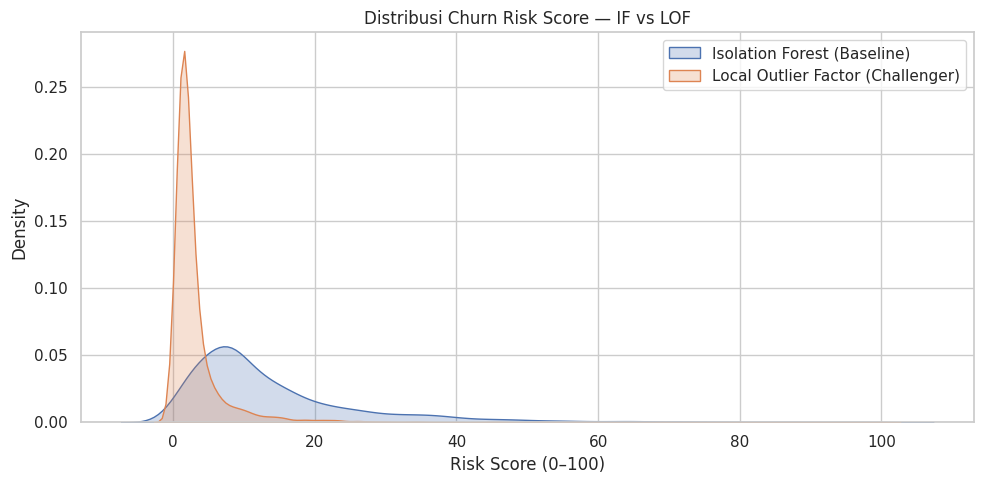

In [16]:
plt.figure(figsize=(10, 5))
sns.kdeplot(rfm['churn_risk_score'], label='Isolation Forest (Baseline)', fill=True)
sns.kdeplot(rfm['churn_risk_lof'],   label='Local Outlier Factor (Challenger)', fill=True)
plt.title('Distribusi Churn Risk Score — IF vs LOF')
plt.xlabel('Risk Score (0–100)')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Pseudo-classification: segmen RFM digunakan sebagai proxy label aktual
rfm['actual_high_risk']   = rfm['Segment'].isin(['Hibernating', 'At Risk']).astype(int)
rfm['pred_high_risk_IF']  = (rfm['churn_risk_score'] >= 70).astype(int)
rfm['pred_high_risk_LOF'] = (rfm['churn_risk_lof']   >= 70).astype(int)

print("=== Classification Report — Isolation Forest ===")
print(classification_report(rfm['actual_high_risk'], rfm['pred_high_risk_IF']))

print("=== Classification Report — LOF ===")
print(classification_report(rfm['actual_high_risk'], rfm['pred_high_risk_LOF']))

=== Classification Report — Isolation Forest ===
              precision    recall  f1-score   support

           0       0.61      0.98      0.75      3602
           1       0.03      0.00      0.00      2276

    accuracy                           0.60      5878
   macro avg       0.32      0.49      0.38      5878
weighted avg       0.38      0.60      0.46      5878

=== Classification Report — LOF ===
              precision    recall  f1-score   support

           0       0.61      1.00      0.76      3602
           1       1.00      0.00      0.00      2276

    accuracy                           0.61      5878
   macro avg       0.81      0.50      0.38      5878
weighted avg       0.76      0.61      0.47      5878



### 6.3 Evaluasi Geometris Isolation Forest

In [18]:
df_eval = rfm.copy()

X_scaled_eval = scaler.fit_transform(df_eval[FEATURES])
df_eval[['scaled_R', 'scaled_F', 'scaled_M']] = X_scaled_eval

def get_risk_tier(score):
    if score < 30:   return 'Low Risk (<30)'
    elif score < 70: return 'Medium Risk (30-70)'
    else:            return 'High Risk (>=70)'

df_eval['Risk_Tier'] = df_eval['churn_risk_score'].apply(get_risk_tier)

scaled_cols     = ['scaled_R', 'scaled_F', 'scaled_M']
normal_centroid = df_eval[df_eval['Risk_Tier'] == 'Low Risk (<30)'][scaled_cols].mean().values
df_eval['Distance_to_Normal'] = np.linalg.norm(df_eval[scaled_cols].values - normal_centroid, axis=1)

high_dist = df_eval[df_eval['Risk_Tier'] == 'High Risk (>=70)']['Distance_to_Normal']
low_dist  = df_eval[df_eval['Risk_Tier'] == 'Low Risk (<30)']['Distance_to_Normal']
t_stat, p_val = stats.ttest_ind(high_dist, low_dist, equal_var=False)

print("Rata-rata jarak Euclidean ke centroid populasi normal:")
for tier in ['Low Risk (<30)', 'Medium Risk (30-70)', 'High Risk (>=70)']:
    avg = df_eval[df_eval['Risk_Tier'] == tier]['Distance_to_Normal'].mean()
    print(f"  {tier}: {avg:.3f}")

print(f"\nT-Test: t={t_stat:.3f}, p={p_val:.3e}")
status = "VALID — isolasi geometris signifikan secara statistik" if p_val < 0.05 else "WARNING — isolasi geometris kurang signifikan"
print(f"Status: {status}")

Rata-rata jarak Euclidean ke centroid populasi normal:
  Low Risk (<30): 0.881
  Medium Risk (30-70): 1.973
  High Risk (>=70): 9.045

T-Test: t=8.367, p=4.721e-12
Status: VALID — isolasi geometris signifikan secara statistik


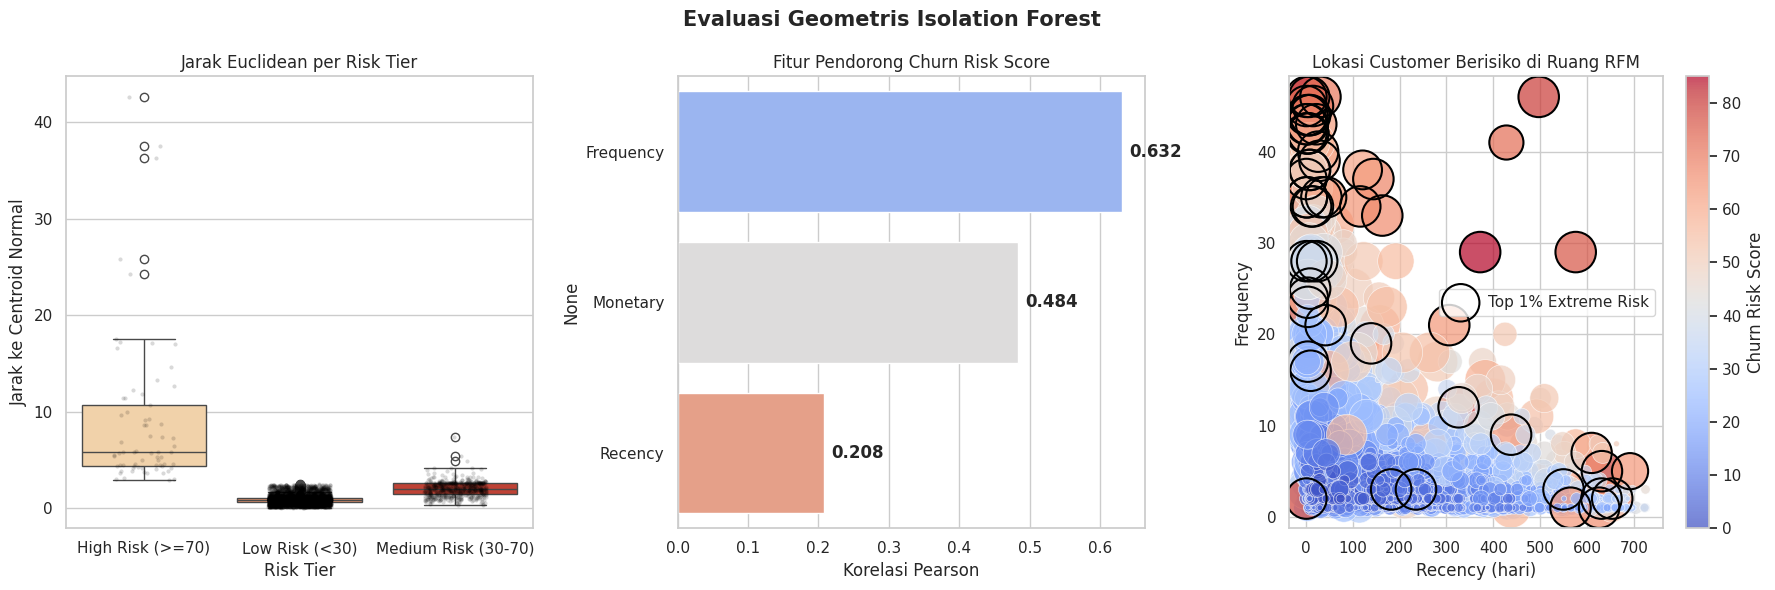

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Evaluasi Geometris Isolation Forest', fontsize=15, fontweight='bold')

# Boxplot separasi geometris
sns.boxplot(x='Risk_Tier', y='Distance_to_Normal', data=df_eval, palette='OrRd', ax=axes[0])
sns.stripplot(x='Risk_Tier', y='Distance_to_Normal', data=df_eval,
              color='black', alpha=0.15, size=3, jitter=0.2, ax=axes[0])
axes[0].set_title('Jarak Euclidean per Risk Tier')
axes[0].set_xlabel('Risk Tier')
axes[0].set_ylabel('Jarak ke Centroid Normal')

# Feature driver analysis
correlations = df_eval[FEATURES].corrwith(df_eval['churn_risk_score']).sort_values(ascending=False)
sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm', ax=axes[1])
axes[1].set_title('Fitur Pendorong Churn Risk Score')
axes[1].set_xlabel('Korelasi Pearson')
for i, v in enumerate(correlations.values):
    axes[1].text(v + (0.01 if v >= 0 else -0.05), i, f'{v:.3f}', va='center', fontweight='bold')

# Distribusi spasial di ruang RFM (Recency vs Frequency, warna = risk score)
q99_rec  = df_eval['Recency'].quantile(0.99)
q99_freq = df_eval['Frequency'].quantile(0.99)
df_plot  = df_eval[(df_eval['Recency'] <= q99_rec) & (df_eval['Frequency'] <= q99_freq)]

sc = axes[2].scatter(
    df_plot['Recency'], df_plot['Frequency'],
    c=df_plot['churn_risk_score'], cmap='coolwarm',
    s=df_plot['Monetary'].clip(upper=df_plot['Monetary'].quantile(0.95)) / 10,
    alpha=0.7, edgecolors='w', linewidths=0.5
)
top_1pct = df_plot.sort_values('churn_risk_score', ascending=False).head(int(len(df_plot) * 0.01))
axes[2].scatter(
    top_1pct['Recency'], top_1pct['Frequency'],
    facecolors='none', edgecolors='black',
    s=top_1pct['Monetary'].clip(upper=df_plot['Monetary'].quantile(0.95)) / 10,
    linewidths=1.5, label='Top 1% Extreme Risk'
)
plt.colorbar(sc, ax=axes[2], label='Churn Risk Score')
axes[2].set_title('Lokasi Customer Berisiko di Ruang RFM')
axes[2].set_xlabel('Recency (hari)')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.show()

### 6.4 Evaluasi Model BG/NBD (CLTV)

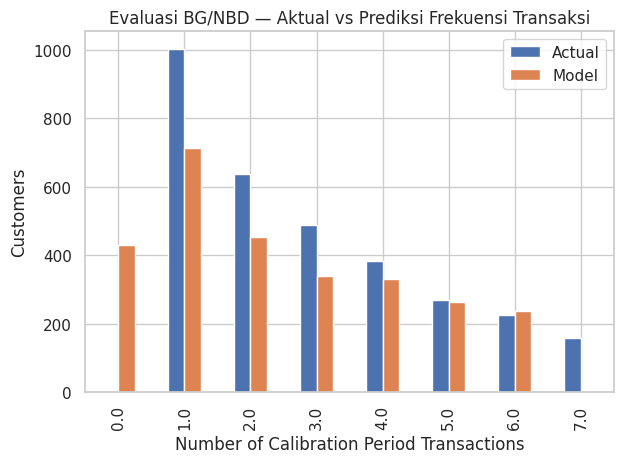

In [20]:
from lifetimes.plotting import plot_period_transactions
from lifetimes.utils import calibration_and_holdout_data

plot_period_transactions(bgf)
plt.title('Evaluasi BG/NBD — Aktual vs Prediksi Frekuensi Transaksi')
plt.tight_layout()
plt.show()

In [21]:
# Evaluasi dengan calibration-holdout split
# Sesuaikan CALIBRATION_END dengan range data
CALIBRATION_END = '2011-06-01'

summary_cal_holdout = calibration_and_holdout_data(
    df_clean, 'Customer ID', 'InvoiceDate',
    calibration_period_end=CALIBRATION_END,
    observation_period_end=df_clean['InvoiceDate'].max()
)

bgf_eval = BetaGeoFitter(penalizer_coef=0.001)
bgf_eval.fit(
    summary_cal_holdout['frequency_cal'],
    summary_cal_holdout['recency_cal'],
    summary_cal_holdout['T_cal']
)

summary_cal_holdout['predicted_freq'] = bgf_eval.predict(
    summary_cal_holdout['duration_holdout'],
    summary_cal_holdout['frequency_cal'],
    summary_cal_holdout['recency_cal'],
    summary_cal_holdout['T_cal']
)

mae = mean_absolute_error(
    summary_cal_holdout['frequency_holdout'],
    summary_cal_holdout['predicted_freq']
)
print(f"MAE BG/NBD (holdout period): {mae:.3f}")

MAE BG/NBD (holdout period): 1.087


### 6.5 Stabilitas Isolation Forest — Bootstrap & Tree Convergence

In [22]:
# Uji stabilitas via bootstrap Spearman correlation
N_BOOTSTRAP      = 5
scores_bootstrap = []

for i in range(N_BOOTSTRAP):
    idx = np.random.choice(len(X_scaled), size=int(0.8 * len(X_scaled)), replace=False)
    clf = IsolationForest(n_estimators=100, random_state=i, contamination='auto')
    clf.fit(X_scaled[idx])
    scores_bootstrap.append(clf.score_samples(X_scaled))

correlations = [
    spearmanr(scores_bootstrap[i], scores_bootstrap[j]).correlation
    for i in range(N_BOOTSTRAP)
    for j in range(i + 1, N_BOOTSTRAP)
]
mean_stability = np.mean(correlations)

print(f"Rata-rata Korelasi Spearman Bootstrap: {mean_stability:.4f}")
status = "SANGAT STABIL" if mean_stability > 0.90 else "KURANG STABIL — pertimbangkan menaikkan n_estimators"
print(f"Status: {status}")

Rata-rata Korelasi Spearman Bootstrap: 0.9415
Status: SANGAT STABIL


  n_estimators= 10 | MAE vs 500 trees: 0.01747
  n_estimators= 30 | MAE vs 500 trees: 0.00759
  n_estimators= 50 | MAE vs 500 trees: 0.00797
  n_estimators=100 | MAE vs 500 trees: 0.00472
  n_estimators=200 | MAE vs 500 trees: 0.00262
  n_estimators=300 | MAE vs 500 trees: 0.00207


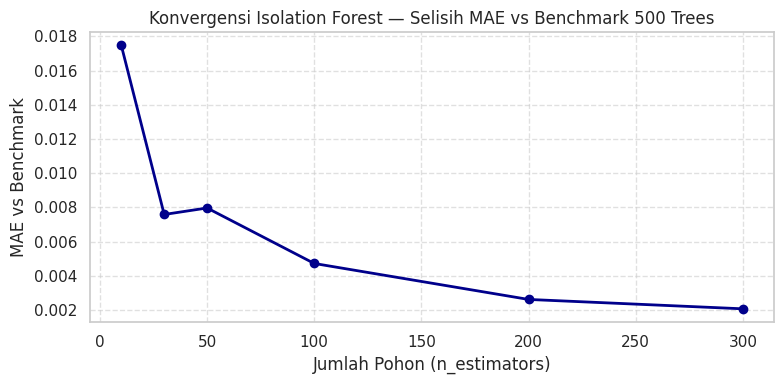

In [23]:
# Analisis konvergensi jumlah pohon (benchmark: 500 trees)
ref_model = IsolationForest(n_estimators=500, random_state=42)
ref_model.fit(X_scaled)
ref_scores = ref_model.score_samples(X_scaled)

tree_sizes     = [10, 30, 50, 100, 200, 300]
score_mae_diff = []

for size in tree_sizes:
    clf = IsolationForest(n_estimators=size, random_state=42)
    clf.fit(X_scaled)
    mae = np.mean(np.abs(clf.score_samples(X_scaled) - ref_scores))
    score_mae_diff.append(mae)
    print(f"  n_estimators={size:3d} | MAE vs 500 trees: {mae:.5f}")

plt.figure(figsize=(8, 4))
plt.plot(tree_sizes, score_mae_diff, marker='o', linewidth=2, color='darkblue')
plt.title('Konvergensi Isolation Forest — Selisih MAE vs Benchmark 500 Trees')
plt.xlabel('Jumlah Pohon (n_estimators)')
plt.ylabel('MAE vs Benchmark')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

---
## 7. Export Output & Aset Model

In [24]:
final_df.to_csv('enriched_customer_analytics.csv')
print("Output disimpan: enriched_customer_analytics.csv")

Output disimpan: enriched_customer_analytics.csv


In [25]:
deployment_assets = {
    'scaler':             scaler,
    'churn_model':        iso_forest,
    'segmentation_model': kmeans,
    'cltv_bgf_params':    bgf.params_,
    'cltv_ggf_params':    ggf.params_,
    'risk_score_params': {
        'min_score': min_score,
        'max_score': max_score
    },
    'metadata': {
        'export_date':   dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'feature_names': FEATURES,
        'k_clusters':    K_OPTIMAL
    }
}

joblib.dump(deployment_assets, 'retail_ai_model_assets.joblib')
print("Aset model disimpan: retail_ai_model_assets.joblib")

Aset model disimpan: retail_ai_model_assets.joblib
